### Implementing Logistic Regression From Scratch

In [3]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import pprint
import pickle

### Data Loading and Analysis

In [4]:
df = pd.read_csv("./data/breast-cancer.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
px.histogram(data_frame = df, x='diagnosis', color = 'diagnosis', color_discrete_sequence=['#05445E','#75E6DA'])

In [6]:
px.histogram(data_frame=df,x='area_mean',color='diagnosis',color_discrete_sequence=['#05445E','#75E6DA'])

In [7]:
px.histogram(data_frame=df,x='radius_mean',color='diagnosis',color_discrete_sequence=['#05445E','#75E6DA'])

In [8]:
px.histogram(data_frame=df,x='perimeter_mean',color='diagnosis',color_discrete_sequence=['#05445E','#75E6DA'])

In [9]:
px.histogram(data_frame=df,x='smoothness_mean',color='diagnosis',color_discrete_sequence=['#05445E','#75E6DA'])

In [10]:
px.histogram(data_frame=df,x='texture_mean',color='diagnosis',color_discrete_sequence=['#05445E','#75E6DA'])

In [11]:
px.scatter(data_frame=df,x='symmetry_worst',color='diagnosis',color_discrete_sequence=['#05445E','#75E6DA'])

In [12]:
px.scatter(data_frame=df,x='concavity_worst',color='diagnosis',color_discrete_sequence=['#05445E','#75E6DA'])

In [13]:
px.scatter(data_frame=df,x='fractal_dimension_worst',color='diagnosis',color_discrete_sequence=['#05445E','#75E6DA'])

### Data Preprocessing

In [14]:
df.drop('id', axis = 1, inplace = True) # drop redundant columns

In [15]:
df['diagnosis'] = (df['diagnosis'] == 'M').astype(int)

In [16]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [17]:
corr = df.corr()

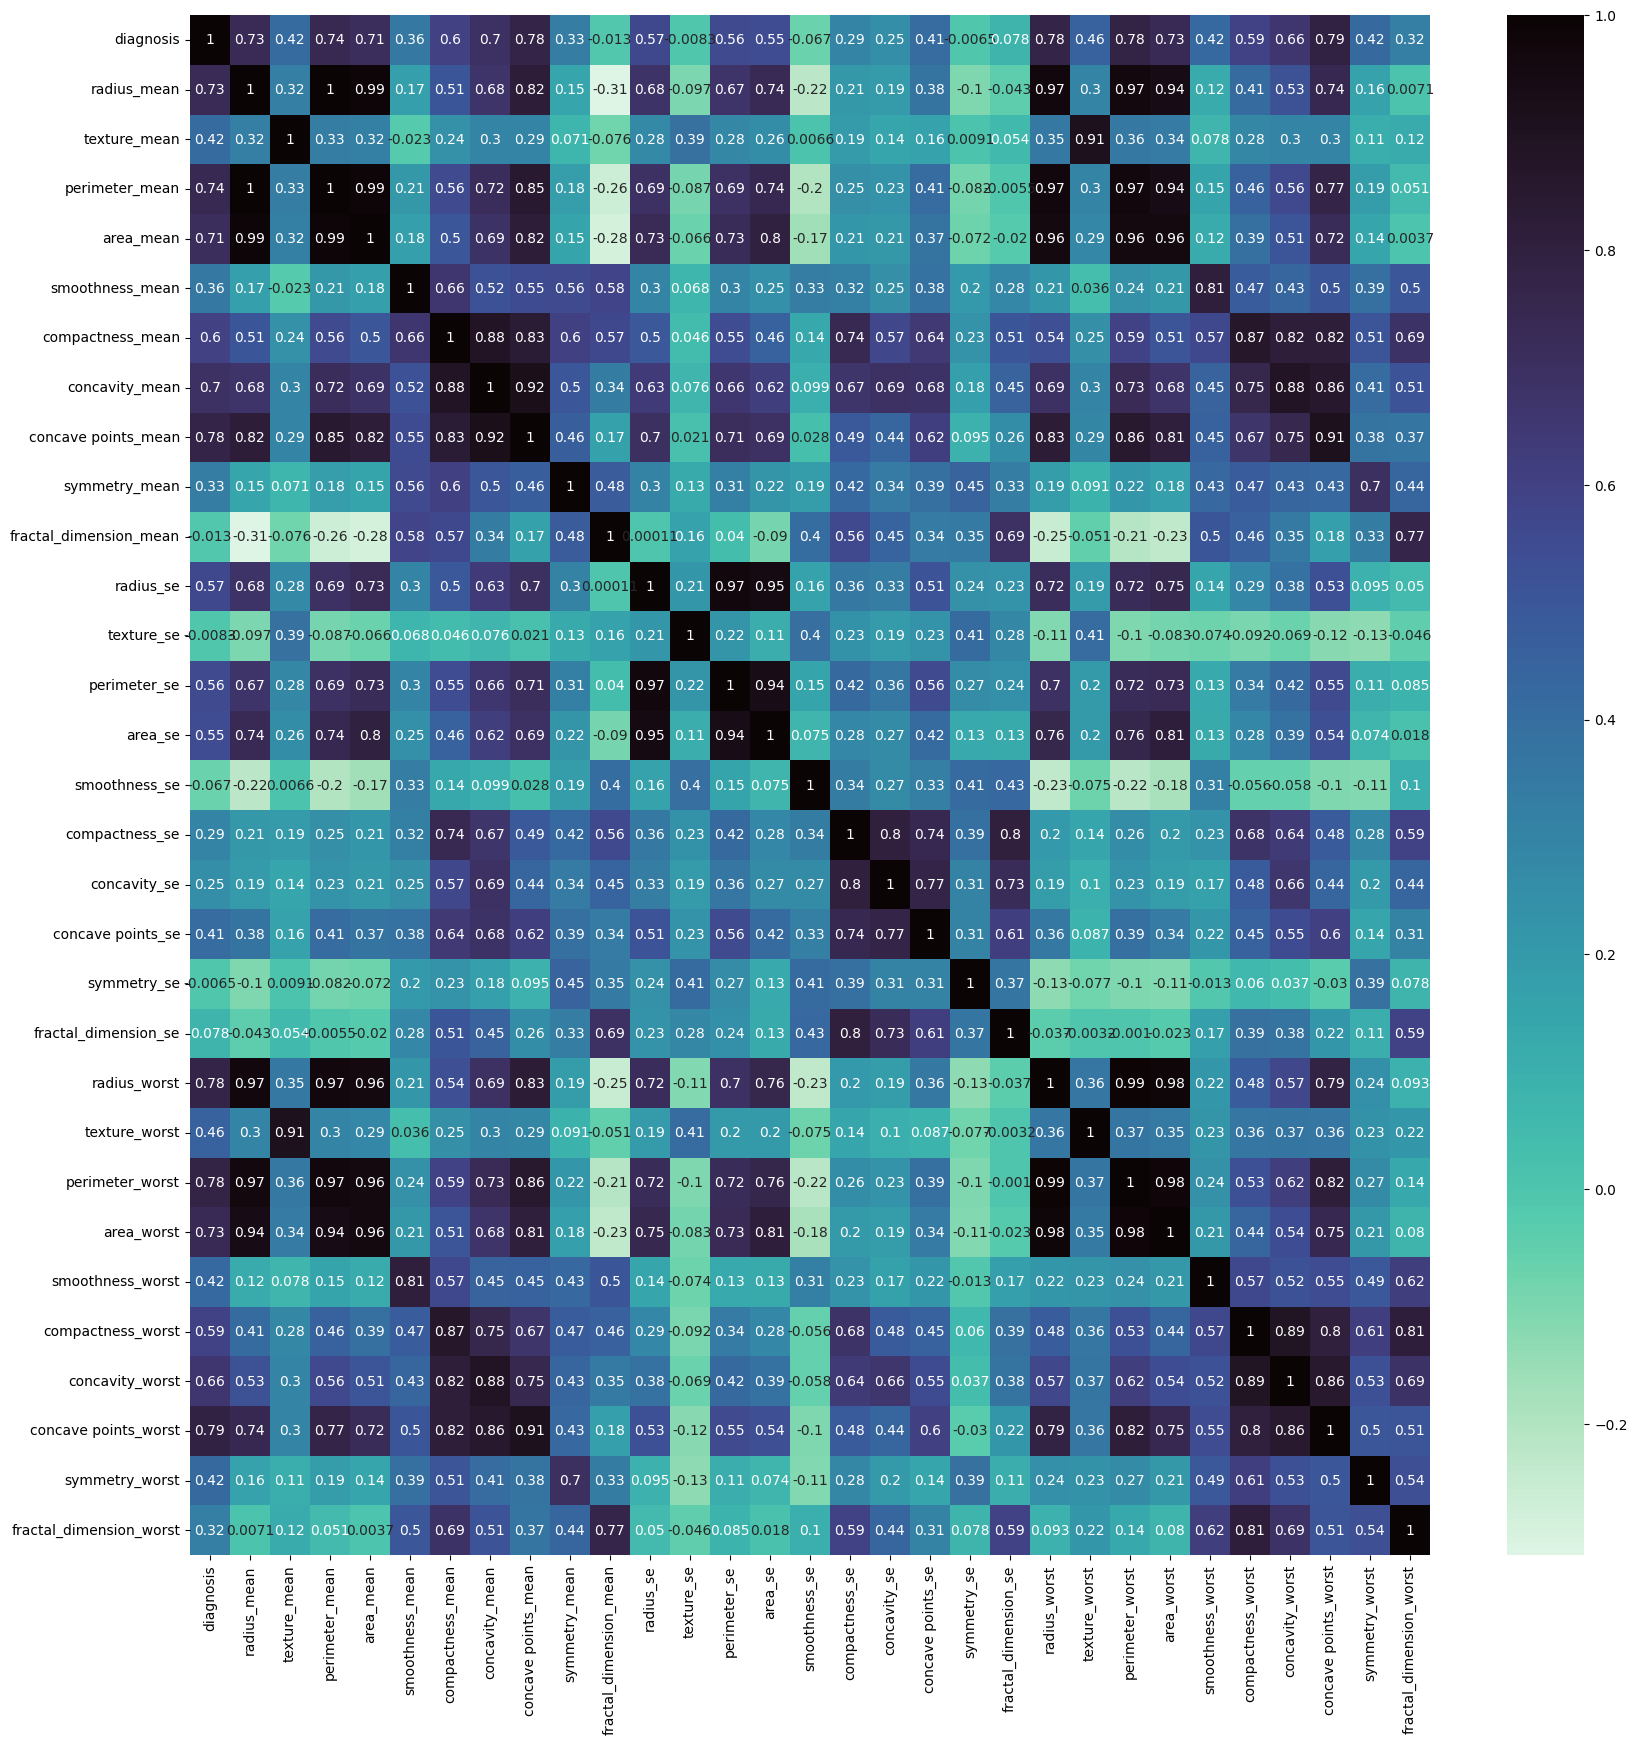

In [18]:
plt.figure(figsize = (20, 20))
sns.heatmap(corr, cmap = 'mako_r', annot = True)
plt.show()

In [19]:
cor_target = abs(corr['diagnosis'])
cor_target

diagnosis                  1.000000
radius_mean                0.730029
texture_mean               0.415185
perimeter_mean             0.742636
area_mean                  0.708984
smoothness_mean            0.358560
compactness_mean           0.596534
concavity_mean             0.696360
concave points_mean        0.776614
symmetry_mean              0.330499
fractal_dimension_mean     0.012838
radius_se                  0.567134
texture_se                 0.008303
perimeter_se               0.556141
area_se                    0.548236
smoothness_se              0.067016
compactness_se             0.292999
concavity_se               0.253730
concave points_se          0.408042
symmetry_se                0.006522
fractal_dimension_se       0.077972
radius_worst               0.776454
texture_worst              0.456903
perimeter_worst            0.782914
area_worst                 0.733825
smoothness_worst           0.421465
compactness_worst          0.590998
concavity_worst            0

In [20]:
# Select highly correlated features (threshold = 0.2)
relevant_features = cor_target[cor_target > 0.2]

# Collec the names of the relevant features
names = [index for index, value in relevant_features.items()]

# Drop the target variable 'diagnosis' from the result
names.remove('diagnosis')

# Display the results
pprint.pprint(names)  # pprint is just a library that supports pretty print style.

['radius_mean',
 'texture_mean',
 'perimeter_mean',
 'area_mean',
 'smoothness_mean',
 'compactness_mean',
 'concavity_mean',
 'concave points_mean',
 'symmetry_mean',
 'radius_se',
 'perimeter_se',
 'area_se',
 'compactness_se',
 'concavity_se',
 'concave points_se',
 'radius_worst',
 'texture_worst',
 'perimeter_worst',
 'area_worst',
 'smoothness_worst',
 'compactness_worst',
 'concavity_worst',
 'concave points_worst',
 'symmetry_worst',
 'fractal_dimension_worst']


In [21]:
X = df[names].values
y = df['diagnosis'].values

In [22]:
def train_test_split(X, y, random_state = 42, test_size = 0.2):
    """
        We are implementing this function again, so we know that X is going to be the input/features, 
        X: numpy.ndarray, shape(n_samples, n_features)
        y: numpy.ndarray, shape(n_samples, )

        Returns:
            Tuple[numpy.ndarray]: A tuple containing X_train, X_test, y_train, y_test values.
    """
    # Get number of samples
    n_samples = len(X)

    np.random.seed(random_state)

    shuffled_indices = np.random.permutation(np.arange(n_samples))  # This shuffles the indices 

    test_size = int(n_samples * test_size)

    # Split the data into test and training
    test_indices = shuffled_indices[:test_size]
    train_indices = shuffled_indices[test_size: ]

    # Split the features and target arrays into test and train 
    X_train, X_test = X[train_indices], X[test_indices]
    y_train, y_test = y[train_indices], y[test_indices]

    return X_train, X_test, y_train, y_test

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

#### We need to then Standardize the data
The reasons for standardization is explained in the section under Linear Regression from Scratch, 
But I would like to do some recap:<br>
- Ensure data are on a similar scale (scale invariance), prevent gradient explosion + gradient vanishing
- Improve convergence
- ensures that all data has a mean of 0, and std of 1. Helps to capture the relative variations in the data.

$$\text{Standardized value} = \frac{x - \mu}{\sigma}$$

In [24]:
def standardize_data(X_train, X_test):
    mean = np.mean(X_train, axis = 0)
    std = np.std(X_train, axis = 0)

    X_train_standardized = (X_train - mean) / std
    X_test_standardized = (X_test - mean)/ std

    return X_train_standardized, X_test_standardized

X_train, X_test = standardize_data(X_train, X_test)

#### Model Implementation

This is an important section as I will be learning the importance of Logistic Regression.

##### Logistic Regression Model
Logistic Regression is commonly used for binary classification. It takes the probaility that a given input belongs to a particular class. The logistic regresion model function is represented as:

$$f_{w, b}(X) = g(w\cdot x + b)$$

In this equation, $f_{w, b}(x)$ represents the predicted probability, $w$ is the weight vector, $b$ is the bias term, $x$ is the input feature vector, and $g(z)$ is the sigmoid function:
$$g(z) = \frac{1}{1 + e^{-z}}$$

#### Model Training
To train a logistic regression mode, we aim to find the best values for $(w, b)$ that best fit our dataset and provide accurate class probabilities.

##### Forward Pass
The forward pass computes the linear combination of input features $x$ with the weight vector $w$ and the bias term $b$ and then applies the sigmoid function to the result:
$$Z = x \cdot w + b$$
$$A = \sigma(Z)$$

##### Cost Function
The cost function measures the error between the predicted probabilities and the true labels. In logistic regression, we use the binary cross-entropy loss function:
$$J(w, b) = -\frac{1}{m}$$
$$\sum_{i = 0}^{m - 1} [y_{i} \log{(f_{w, b}(X_i)) + (1 - y_{i})\log{(1 - f_{w, b}(x_i))}}]$$

Here, $m$ is the number of samples, $y_{i}$ is the true label of sample $i$, and $f_{w, b}(x_i)$ is the predicted probability of sample $i$ belonging to the positive class.

##### Backward Pass (Gradient Computation)
The backward pass calculates the gradients of the cost function with respect to the parameters $(w, b)$. These gradients are essential for updating the model parameters during training:
$$\frac{\partial J(w, b)}{\partial b} = \frac{1}{m}\sum_{i = 0}^{m - 1}(f_{w, b}(X^{(i)}) - y^{(i)})$$
$$\frac{\partial J(w, b)}{\partial w} = \frac{1}{m}\sum_{i = 0}^{m - 1}(f_{w, b}(X^{(i)}) - y^{(i)})X^{(i)}$$

##### Training Process

The training process involves iteratively updating weight and bias to minmize the cost function. This is typically done through an optimization algorithm like gradient descent. The update equations for parameters are:
$$w \leftarrow w - \alpha \frac{\partial J}{\partial w}$$
$$b \leftarrow b - \alpha \frac{\partial J}{\partial b}$$

Here, $\alpha$ represents the learning rate, which controls the step size during parameter updates.

By iteratively performing the forward pass, cost computation, backward pass, and parameter updates, logistic regression model learns to make better predictions and fit the data from epoch to epoch.

In [25]:
def sigmoid(z):
    """
        Parameters:
            z (float or numpy.ndarray): The input value(s) fow which to compute the sigmoid.
        
        Returns:
            float or numpy.ndarray: The sigmoid of the input values.
    """
    # Compute the sigmoid function using the formula: 1/ (1 + e^(-z))
    sigmoid_result = 1 / (1 + np.exp(-z))
    return sigmoid_result


In [26]:
# Visualize the shape of the Logistic function
z = np.linspace(-12, 12, 200)

fig = px.line(x = z, y= sigmoid(z), title = 'Logistic Function', template = "plotly_dark")
fig.update_layout(
    title_font_color = "#41BEE9",
    xaxis=dict(color="#41BEE9"), 
    yaxis=dict(color="#41BEE9") 
)
fig.show()


In [27]:
class LogisticRegression:
    """
        Parameters:
            Learning Rate (float): Learning rate for the model.
        Methods:
            initialize_parameter(): Initializes the parameters of the model.
            sigmoid(z): Computes the sigmoid activation function for given input z.
            forward(X): Computes forward propagation for given input X.
            compute_cost(predictions): Computes the cost function for given predictions.
            compute_gradient(predictions): Computes the gradients for the model using given predictions.
            fit(X, y, iterations, plot_cost): Trains the model on given input X and labels y for specified iterations.
            predict(X): Predicts the labels for given input X.
    """
    def __init__(self, learning_rate = 0.0001):
        np.random.seed(1)
        self.learning_rate = learning_rate

    def initialize_parameter(self):
        self.W = np.zeros(self.X.shape[1])
        self.b = 0.0
    
    def forward(self, X):
        """
            Computes the forward propogation for given input X.T
            Parameters:
                X (numpy.ndarray) : Input array
            Returns:
                numpy.ndarray: Output array
        """
        Z = np.matmul(X, self.W) + self.b
        A = sigmoid(Z)
        return A

    def compute_cost (self, predictions):
        """
            Compute the cost function for given predictions.
            Parameters:
                predictions (numpy.ndarray): Predictions of the model.
            Returns:
                float: Cost of the model.
        """
        m = self.X.shape[0]

        # compute the cost
        cost = np.sum((-np.log(predictions + 1e-8)* self.y) + (-np.log(1 - predictions + 1e-8)) * (1 - self.y)) # we are adding small values epsilon to avoid log of 0
        cost = cost /m
        return cost


    def compute_gradient(self, predictions):
        """
            Compute the gradients for the model using given predictions.

            Parameters:
                predictions (numpy.ndarray): Predictions of the model.
        """
        # Get training shape
        m = self.X.shape[0]

        # compute gradients
        self.dW = np.matmul(self.X.T, (predictions - self.y))
        # self.dW = np.array([np.mean(grad) for grad in self.dW])
        self.db = np.sum(np.subtract(predictions, self.y))

        # scale gradients
        self.dW = self.dW / m
        self.db = self.db / m

    
    def fit(self, X, y, iterations, plot_cost = True):
        """
            Trains the model on given input X and labels y for specified iterations.

            Parameters:
                X (numpy.ndarray): Input features array of shape (n_samples, n)
                y (numpy.ndarray): Labels array of shape (n_samples, 1)

                iterations (int): Number of iterations for training.
                plot_cost (bool): Whether to plot cost over iterations or not.
            
            Returns:
                None.
        """
        self.X = X
        self.y = y

        self.initialize_parameter()
        
        costs = []
        for i in range(iterations):
            # forward prorpogation
            predictions = self.forward(self.X)
            if i % 10000 == 0:
                print("predictions: ")
                print(predictions)

            # compute cost
            cost = self.compute_cost(predictions)
            costs.append(cost)
            if i % 10000 == 0:
                print("cost: ")
                print(cost)

            # compute gradients
            self.compute_gradient(predictions)
            if i % 10000 == 0:
                print("dW: ")
                print(self.dW)
                print("db: ")
                print(self.db)

            # update parameters
            self.W = self.W - self.learning_rate * self.dW
            self.b = self.b - self.learning_rate * self.db
            if i % 10000 == 0:
                print("W: ")
                print(self.W)
                print("b: ")
                print(self.b)

            # print cost every 100 iterations
            if i % 10000 == 0:
                print(f"Cost after iteration {i}: {cost}")
        
        if plot_cost:
            fig = px.line(y=costs, title = "Cost vs Iteration", template = "plotly_dark")
            fig.update_layout(
                title_font_color="#41BEE9", 
                xaxis=dict(color="#41BEE9",title="Iterations"), 
                yaxis=dict(color="#41BEE9",title="cost")
            )
            fig.show()
    
    def predict (self, X):
        """
            Predicts the labels for given input X
        """
        predictions = self.forward(X)
        return np.round(predictions)
    
    def save_model(self, filename = None):
        model_data = {
            'learning_rate': self.learning_rate,
            'W': self.W,
            'b': self.b
        }

        with open (filename, 'wb') as file:
            pickle.dump(model_data, file)
    
    @classmethod
    def load_model(cls, filename):
        """
            Load a trained model from a file using pickle.

            Parameters:
                filename(str): The name of the file to load the model from.
            
            Returns:
                LogisticRegression: An instance of the LogisticRegression on class with loaded parameters.
        """
        with open(filename, 'rb') as file:
            model_data = pickle.load(file)

        # Create a new instance of the class and initialize it with the loaded parameters.
        loaded_model = cls(model_data['learning_rate'])
        loaded_model.W = model_data['W']
        loaded_model.b = model_data['b']

        return loaded_model


In [28]:
lg = LogisticRegression()
lg.fit(X_train, y_train, 100000)

predictions: 
[0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 

In [29]:
lg.save_model("model.pkl")

### Evaluation

In classification tasks, it's crucial to evaluate the performance of your model. There are several metrics that can help you understand how well your model is performing. Here are four commonly used classification metrics:

##### 1. Accuracy
**Formula:**
$$\text{Accuracy} = \frac{\text{Number of Correct Predictions}}{\text{Total Number of Predictions}}$$

**Description:**
- **Accuracy** measures the proportion of correctlly predicted instances out of all instances in a classification model.
- It is widely used metric for evaluating classification performance.

**Interpretation:**
- A higher accuracy value indicates a better classification model.
- However, accuracy alone may not provide a complete picture, especially in imbalanced datasets.

**When to use/When not to use**

When not to use:<br>
- Data is imbalanced.
- One mistake is much worse than the other.

When to use:<br>
- Classes are balanced
- False positives and false negatives are equally bad

##### 2. Precision
**Formula:**
$$\text{Precision} = \frac{\text{True Positives}}{\text{True Positives + False Positives}}$$

**Description:**
- **Precision** measures the proportion of true positive predictions out of all positive predictions made by the model.
- It is a useful metrix when the cost of false positives is high.

**Interpretation**
- Higher precision means the model makes fewer false positive predictions.

**When to Use / When not to use**

When to use:<br>
- False positives are expensive.

When not to use<br>
- Missing positivs is dangerous.
- You care about catching everything.

##### 3. Recall (Sensitivity)
**Formula:**
$$\text{Recall(Sensitivity)} = \frac{\text{True Positives}}{\text{True Positives + False Negatives}}$$

**Description:**
- **Recall**, also known as sensitivity or true positive rate, measures the proportion of true positive predictions out of all actual positive instances in the dataset.
- It is a valuable metric when it's essential to capture all positive instances. 

**Interpretation:**
- Higher recall means the model captures more of hte actual positive instances. 

**When to Use / When not to use**

When to use:
- False negatives are very dangerous.

Recall alone fails wheh
- False alarams are costly.
- The system is flooed with positives.

##### 4. F1-Score
**Formula:**
$$\text{F1 - Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

**Description:**
- The **F1-Score** is the harmonic mean of precision and recall.
- It provides a balance between precision and recall, making it a suitable metric when there is a trade-off between false positives and false negatives.

**Interpretation:**
- A higher F1-Score indicates a model that achieves a balance betwen precision and recall.

**WHen to use / When not to use**

When to use:
- Data is imbalanced
- You care abotu both FP and FN
- You need one bumber to compare models

When Not to use:
- One error type clearly matters more
- Stakeholders care about specific failure types.

##### 5. F2-Score + F0.5-score
F2 and F0.5 are both variants of the F-score family.
General form:
$$F_{\beta} = (1 + \beta^2) \frac{P \cdot R}{\beta^2P + R}$$

Where:
- P = Precision
- R = Recall
- $\beta$ controls **how much more recall matters than precision**.

The **number** following the hyphen after F is equivalent to what we will substitute in $\beta$

**F2**

- Recall >> Precision

**F0.5**

- Precision >> Recall


**Understand how $\beta$ term affects relationship between Precision and Recall**

Rewrite the F-score as:
$$F_{\beta} = \frac{1}{\frac{1}{1 + \beta^2} (\frac{\beta^2}{R} + \frac{1}{P})}$$
We can now see that:<br>
- Recall appears as $\frac{\beta^2}{R}$
- Precision appears as $\frac{1}{P}$

#### **For F2:**
$$\frac{4}{R} ~~\text{vs}~~ \frac{1}{P}$$

Now it becomes obvious that Recall is penalized much heavily compared to Precision for F2-score
We should use F2 when:
- False negatives are very dangerous.
- You must catch almost everything.
- Some false positives are acceptable.

**Why wouldn't I just choose recall than F2**

The truth is that we can, especailly when false negatives become extremely serious.<br>
But the problem with using recall alone, is that you can always get
<code>Recall = 1.0</code>. By adding some thing unreasonable but legal: "Predict positive for everything."<br>

So F2 exists and says:
- False negatives are much worse, but false positives are <i>not free</i>.
Given an example:<br>

**Model A**:

<code>Recall = 0.98</code><br>
<code>Precision = 0.05</code>

**Model B**:

<code>Recall = 0.92</code><br>
<code>Precision = 0.60</code>

Recall prefers **Model A**<br>
**F2 prefers Model B** since Model A is practically useless.
<br>
<br>

#### **For F0.5**
$$\frac{1}{4R} ~~\text{vs}~~ \frac{1}{P}$$
As you can see in this case, the precision will influence the size of the denominator much more than the recall. Thus, it is used when false positives are bad, but false negatives still matter.

In [30]:
class ClassificationMetrics:
    @staticmethod
    def accuracy(y_true, y_pred):
        """
        Parameters:
            y_true (numpy array): A numpy array of true labels for each data point.
            y_pred (numpy array): A numpy array of predicted labels for each data point.

        Returns:
        float: The accraucy of the model, expressed as a percentage.
        """
        y_true = y_true.flatten()
        total_samples = len(y_true)
        correct_predictions = np.sum(y_true == y_pred)
        return (correct_predictions / total_samples)

    
    @staticmethod
    def precision(y_true, y_pred):
        true_positives = np.sum((y_true == 1) & (y_pred == 1))
        false_positives = np.sum((y_true == 0) & (y_pred == 1))
        return true_positives / (true_positives + false_positives)
    
    @staticmethod
    def recall(y_true, y_pred):
        true_positives = np.sum((y_true == 1) & (y_pred == 1))
        false_negatives = np.sum((y_true == 1) & (y_pred == 0))
        return true_positives / (true_positives + false_negatives)
    
    @staticmethod
    def f1_score(y_true, y_pred):
        precision_value = ClassificationMetrics.precision(y_true, y_pred)
        recall_value = ClassificationMetrics.recall(y_true, y_pred)
        return 2 * (precision_value * recall_value) / (precision_value + recall_value)
    

In [31]:
model = LogisticRegression.load_model("model.pkl")

In [32]:
y_pred = model.predict(X_test)
accuracy = ClassificationMetrics.accuracy(y_test, y_pred)
precision = ClassificationMetrics.precision(y_test, y_pred)
recall = ClassificationMetrics.recall(y_test, y_pred)
f1_score = ClassificationMetrics.f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy: .2%}")
print(f"Precision: {precision: .2%}")
print(f"Recall: {recall:.2%}")
print(f"F1-Score: {f1_score:.2%}")

Accuracy:  98.23%
Precision:  100.00%
Recall: 95.24%
F1-Score: 97.56%


### Using the Scikit Learn Library for Logistic Regression

In [33]:
from sklearn.linear_model import LogisticRegression

In [37]:
print("X_train")
print(X_train)

print("X_test: ")
print(X_test)

print("y_train: ")
print(y_train)

print("y_test")
print(y_test)

X_train
[[ 1.86296881  2.77394126  1.79517984 ...  0.79114367 -0.05862424
  -0.09456763]
 [-1.44091832 -0.43819344 -1.36268883 ...  0.93065528  2.09966648
   1.88871131]
 [ 1.96461819  1.71409986  2.08259475 ...  2.69831332  1.89335928
   2.50076512]
 ...
 [ 0.04457439 -0.55698885 -0.06891115 ... -1.24127981 -0.70928541
  -1.27263083]
 [-0.04295702  0.09522124 -0.03524254 ...  1.04870356  0.43492607
   1.2148906 ]
 [-0.5512039   0.3048602  -0.60596643 ... -0.61301765 -0.33475849
  -0.84700075]]
X_test: 
[[-0.46931968 -0.14236958 -0.44706705 ... -0.19616923  0.17307462
   0.20415955]
 [ 1.35754552  0.48887662  1.29836264 ...  0.99044597 -0.56169641
  -1.00927924]
 [ 0.37493487  0.06261074  0.39916456 ...  0.56884496 -0.10782057
  -0.20630957]
 ...
 [ 0.54717409  0.10220921  0.49770682 ...  0.57804353 -0.40458554
  -1.12270573]
 [-0.7375611  -0.99723066 -0.743515   ... -0.27926296 -0.38236785
  -0.32422819]
 [ 0.02480923  2.01225304  0.02347222 ... -0.4922098  -1.61068918
  -0.33152791]]

In [45]:
# We can choose different types of solvers here:
#            liblinear - Used only for binary classification purposes
#            lbfgs - default sovler, userd for multiclassifcation purposes
#            

model = LogisticRegression(solver = "lbfgs", random_state=0)

In [46]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",0
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

In [47]:
y_pred_scikit = model.predict(X_test)

In [48]:
y_pred_scikit

array([0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 1])

In [49]:
scikit_accuracy = ClassificationMetrics.accuracy(y_test, y_pred)
scikit_precision = ClassificationMetrics.precision(y_test, y_pred)
scikit_recall = ClassificationMetrics.recall(y_test, y_pred)
scikit_f1_score = ClassificationMetrics.f1_score(y_test, y_pred)

print(f"Accuracy Scikit: {scikit_accuracy: .2%}")
print(f"Precision Scikit: {scikit_precision: .2%}")
print(f"Recall Scikit: {scikit_recall:.2%}")
print(f"F1-Score Scikit: {scikit_f1_score:.2%}")

Accuracy Scikit:  98.23%
Precision Scikit:  100.00%
Recall Scikit: 95.24%
F1-Score Scikit: 97.56%
